In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [3]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [4]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_or_test = []
for i in range(len(df)):
    if df['fragment'][i] in val_texts:
        train_or_test.append(0)
    else:
        train_or_test.append(1)

df['train_or_test'] = train_or_test
df

,fragment,textbook-assigned cefr level,label,train_or_test
0,"Весной, летом и осенью почти каждую субботу он...",1,1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1,0
2,На каждой двери красные плакаты и красные фона...,1,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1,0
...,...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6,1
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6,1
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6,1
7320,Mapillary использует программное обеспечение д...,6,6,1


In [6]:
model_name = 'cointegrated/rubert-tiny2'
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [7]:
training_args = TrainingArguments(
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    learning_rate=2e-5
)

In [8]:
def evaluate_model(model, val_dataset, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    return true_labels, predictions

# A/B/C

In [9]:
df_level1 = df.copy()
df_level1['label'] = df_level1['label'].map({1: 0, 2: 0, 3:1, 4:1, 5:2, 6:2})
df_level1

,fragment,textbook-assigned cefr level,label,train_or_test
0,"Весной, летом и осенью почти каждую субботу он...",1,0,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,0,0
2,На каждой двери красные плакаты и красные фона...,1,0,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,0,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,0,0
...,...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,2,1
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,2,1
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,2,1
7320,Mapillary использует программное обеспечение д...,6,2,1


In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label={0: 'A', 1: 'B', 2: 'C'},
    label2id={'A': 0, 'B': 1, 'C': 2}
)

model = model.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [11]:
train_texts, val_texts, train_labels, val_labels = [],[],[],[]
for i in range(len(df_level1)):
    if df_level1['train_or_test'][i] == 1:
        train_texts.append(df_level1['fragment'][i])
        train_labels.append(df_level1['label'][i])
    else:
        val_texts.append(df_level1['fragment'][i])
        val_labels.append(df_level1['label'][i])

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 5833
Валидационная выборка: 1489


In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [13]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,0.687700,0.634826
2,0.583200,0.609264
3,0.463300,0.603732
4,0.429600,0.620874
5,0.375100,0.633562


Обучение завершено за 71.78 секунд (0:01:11)


In [14]:
true_labels, predictions = evaluate_model(model, val_dataset, device)

accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.7475
F1 Micro: 0.7475
F1 Macro: 0.7199
F1 Weighted: 0.7462
MAE: 0.2565


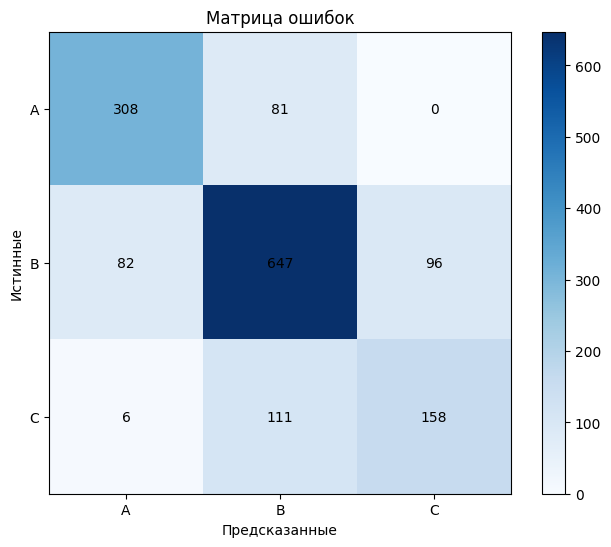

In [15]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(['A', 'B', 'C'])
ax.set_yticklabels(['A', 'B', 'C'])

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [16]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.7475
0.7475
0.7199
0.7462
0.2565
71.78


# A1/A2

In [17]:
df_A = df.copy()
df_A = df_A[df_A['label'] <=2]
df_A['label'] = df_A['label'].map({1: 0, 2: 1})
df_A

,fragment,textbook-assigned cefr level,label,train_or_test
0,"Весной, летом и осенью почти каждую субботу он...",1,0,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,0,0
2,На каждой двери красные плакаты и красные фона...,1,0,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,0,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,0,0
...,...,...,...,...
1894,"В самом деле, мне очень жалко, что у людей ест...",2,1,1
1895,"Я думаю, что счастлива баллов на 8. Если бы у ...",2,1,1
1896,"У́тром пьём крепкий кофе или чай, потому что м...",2,1,0
1897,Я был там с девушкой. Мы спали в лесу в палатк...,2,1,1


In [18]:
model_A = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: 'A1', 1: 'A2'},
    label2id={'A1': 0, 'A2': 1}
)

model_A = model_A.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [19]:
train_texts, val_texts, train_labels, val_labels = [],[],[],[]
for i in range(len(df_A)):
    if df_A['train_or_test'][i] == 1:
        train_texts.append(df_A['fragment'][i])
        train_labels.append(df_A['label'][i])
        
    else:
        val_texts.append(df_A['fragment'][i])
        val_labels.append(df_A['label'][i])

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 1510
Валидационная выборка: 389


In [20]:
trainer = Trainer(
    model=model_A,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [21]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,0.684800,0.594643
2,0.562100,0.477184
3,0.441700,0.442266
4,0.380900,0.422773
5,0.361800,0.417930


Обучение завершено за 20.46 секунд (0:00:20)


In [22]:
true_labels, predictions = evaluate_model(model_A, val_dataset, device)

accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.8123
F1 Micro: 0.8123
F1 Macro: 0.8012
F1 Weighted: 0.8113
MAE: 0.1877


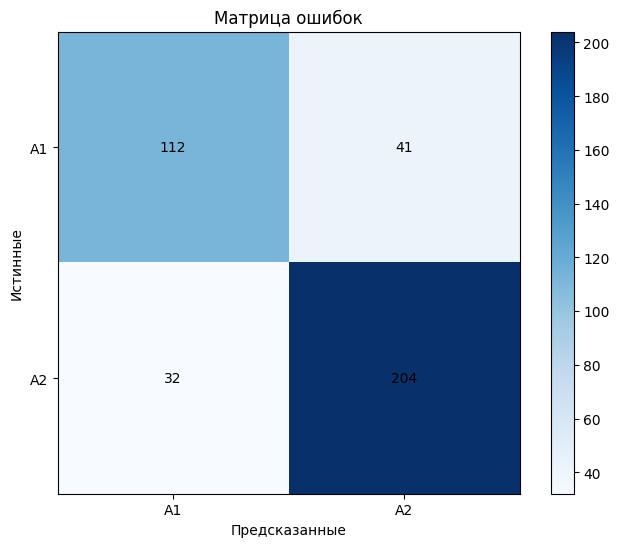

In [23]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_xticklabels(['A1', 'A2'])
ax.set_yticklabels(['A1', 'A2'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [24]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.8123
0.8123
0.8012
0.8113
0.1877
20.46


# B1/B2

In [25]:
df_B = df.copy()
df_B = df_B[(df_B['label'] <= 4) & (df_B['label'] >= 3)]
df_B['label'] = df_B['label'].map({3: 0, 4: 1})
df_B = df_B.reset_index()
df_B

,index,fragment,textbook-assigned cefr level,label,train_or_test
0,1899,В такой ситуации особенно сложно работающим ст...,3,0,1
1,1900,"В те времена люди, которые работали на заводах...",3,0,0
2,1901,"Сначала я изучала русский язык, затем поступил...",3,0,1
3,1902,В наше время люди ездят на автомобилях и поезд...,3,0,1
4,1903,Журналисты решили добиться своей цели и положи...,3,0,1
...,...,...,...,...,...
4086,5985,"Старшее поколение любило играть в карты, молод...",4,1,1
4087,5986,Одним из самых ярких представителей этой эпохи...,4,1,1
4088,5987,"Я не только за маузер хватаюсь, но и тру нос д...",4,1,1
4089,5988,"— Мне трудно сказать, красивый ли это город. И...",4,1,1


In [26]:
len(df_B[df_B['label']==0]), len(df_B[df_B['label']==1])

(2375, 1716)

In [27]:
model_B = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: 'B1', 1: 'B2'},
    label2id={'B1': 0, 'B2': 1}
)

model_B = model_B.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [28]:
train_texts, val_texts, train_labels, val_labels = [],[],[],[]
for i in range(len(df_B)):
    if df_B['train_or_test'][i] == 1:
        train_texts.append(df_B['fragment'][i])
        train_labels.append(df_B['label'][i])
        
    else:
        val_texts.append(df_B['fragment'][i])
        val_labels.append(df_B['label'][i])

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 3266
Валидационная выборка: 825


In [29]:
trainer = Trainer(
    model=model_B,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [30]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,0.599600,0.591480
2,0.533300,0.542005
3,0.464500,0.542589
4,0.391900,0.552507
5,0.340300,0.561061


Обучение завершено за 41.22 секунд (0:00:41)


In [31]:
true_labels, predictions = evaluate_model(model_B, val_dataset, device)

accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.7261
F1 Micro: 0.7261
F1 Macro: 0.7109
F1 Weighted: 0.7216
MAE: 0.2739


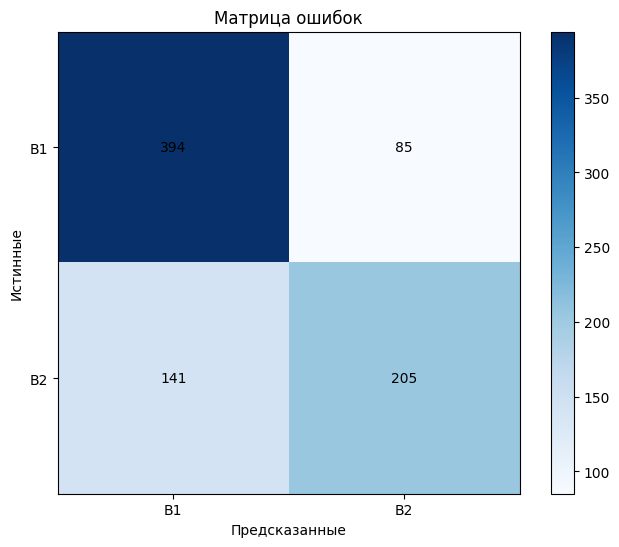

In [32]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_xticklabels(['B1', 'B2'])
ax.set_yticklabels(['B1', 'B2'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [33]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.7261
0.7261
0.7109
0.7216
0.2739
41.22


# C1/C2

In [34]:
df_C = df.copy()
df_C = df_C[df_C['label'] >= 5]
df_C['label'] = df_C['label'].map({5: 0, 6: 1})
df_C = df_C.reset_index()
df_C

,index,fragment,textbook-assigned cefr level,label,train_or_test
0,5990,Он увлёкся энтомологией ещё мальчиком и в детс...,5,0,0
1,5991,"Оказывается, доля этих людей в стране с 2003 г...",5,0,1
2,5992,Над заходом нависал балкон с белой же крашеной...,5,0,1
3,5993,"км, австралийской пустыне. Кстати, не по этой ...",5,0,1
4,5994,Кому-то не нравится постоянный шум в плацкарте...,5,0,1
...,...,...,...,...,...
1327,7317,Утечка мозгов стала ключевым трендом междунаро...,6,1,1
1328,7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,1,1
1329,7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,1,1
1330,7320,Mapillary использует программное обеспечение д...,6,1,1


In [35]:
model_C = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: 'C1', 1: 'C2'},
    label2id={'C1': 0, 'C2': 1}
)

model_C = model_C.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [36]:
train_texts, val_texts, train_labels, val_labels = [],[],[],[]
for i in range(len(df_C)):
    if df_C['train_or_test'][i] == 1:
        train_texts.append(df_C['fragment'][i])
        train_labels.append(df_C['label'][i])
        
    else:
        val_texts.append(df_C['fragment'][i])
        val_labels.append(df_C['label'][i])

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 1057
Валидационная выборка: 275


In [37]:
trainer = Trainer(
    model=model_C,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [38]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,0.588100,0.343125
2,0.334000,0.331383
3,0.332500,0.317960
4,0.305800,0.309585
5,0.276000,0.306138


Обучение завершено за 14.47 секунд (0:00:14)


In [39]:
true_labels, predictions = evaluate_model(model_C, val_dataset, device)

accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.8909
F1 Micro: 0.8909
F1 Macro: 0.4712
F1 Weighted: 0.8395
MAE: 0.1091


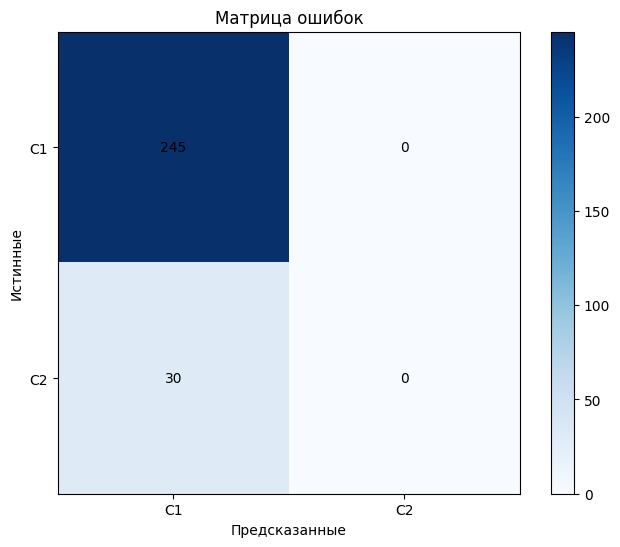

In [40]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_xticklabels(['C1', 'C2'])
ax.set_yticklabels(['C1', 'C2'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [41]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.8909
0.8909
0.4712
0.8395
0.1091
14.47


# Двухэтапная классификация

In [104]:
df

,fragment,textbook-assigned cefr level,label,train_or_test
0,"Весной, летом и осенью почти каждую субботу он...",1,1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1,0
2,На каждой двери красные плакаты и красные фона...,1,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1,0
...,...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6,1
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6,1
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6,1
7320,Mapillary использует программное обеспечение д...,6,6,1


In [105]:
df['label'] = df['label']-1


In [106]:
df

,fragment,textbook-assigned cefr level,label,train_or_test
0,"Весной, летом и осенью почти каждую субботу он...",1,0,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,0,0
2,На каждой двери красные плакаты и красные фона...,1,0,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,0,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,0,0
...,...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,5,1
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,5,1
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,5,1
7320,Mapillary использует программное обеспечение д...,6,5,1


In [108]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)

In [109]:
true_labels, preds = evaluate_model(model, val_dataset, device)

In [110]:
labels=[]
i = 0
for pred, text in zip(preds, val_texts):
    if pred == 1:
        _, predictions = evaluate_model(model_A, [val_dataset[i]], device)
        labels.append(predictions[0])
    elif pred == 2:
        _, predictions = evaluate_model(model_B, [val_dataset[i]], device)
        labels.append(predictions[0]+2)
    else:
        _, predictions = evaluate_model(model_C, [val_dataset[i]], device)
        labels.append(predictions[0]+4)
    i+=1
    # print(predictions[0], len(labels))

In [111]:
set(labels)

{1, 2, 3, 4, 5}

In [112]:
set(true_labels)

{1, 2, 3, 4, 5, 6}

In [115]:
labels[:10], true_labels[:10]

([1, 3, 4, 2, 5, 5, 3, 2, 3, 3], [1, 4, 4, 1, 4, 5, 3, 2, 3, 3])

In [113]:
accuracy = accuracy_score(true_labels, labels)
f1_micro = f1_score(true_labels, labels, average="micro")
f1_macro = f1_score(true_labels, labels, average="macro")
f1_weighted = f1_score(true_labels, labels, average="weighted")
mae = mean_absolute_error(true_labels, labels)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.5659
F1 Micro: 0.5659
F1 Macro: 0.4842
F1 Weighted: 0.5572
MAE: 0.5474


In [114]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
print(classification_report(true_labels, labels))

              precision    recall  f1-score   support

           1       0.72      0.71      0.71       153
           2       0.56      0.58      0.57       227
           3       0.55      0.65      0.60       475
           4       0.55      0.43      0.48       343
           5       0.53      0.56      0.54       237
           6       0.00      0.00      0.00        30

    accuracy                           0.57      1465
   macro avg       0.48      0.49      0.48      1465
weighted avg       0.55      0.57      0.56      1465

